In [46]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import matplotlib.pyplot as plt 
import torch.optim as optim
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import time

In [47]:
file_location='./input.txt'

with open(file_location) as f:
    text=f.read().strip()
chars= sorted(list(set(text)))
char_to_idx= dict()
idx_to_char = dict()
for index,val in enumerate(chars):
    char_to_idx[val]=index
    idx_to_char[index]=val

#encode text
vocab_size=len(char_to_idx)
encoded_text= [char_to_idx[ch]for ch in text]
print(f" text length: {len(text)} characters")
print(f"vocab_size: {vocab_size}")
print(f"First 20 encoded: {encoded_text[:20]}")
print(f"Which decodes to: {''.join([idx_to_char[i] for i in encoded_text[:20]])}")



 text length: 2386 characters
vocab_size: 45
First 20 encoded: [13, 23, 42, 38, 1, 21, 26, 19, 36, 19, 21, 38, 23, 36, 1, 34, 36, 23, 22, 27]
Which decodes to: Next character predi


In [48]:
def create_input_output_seq(encoded_text,seq_len):
    inputs=[]
    targets=[]
    for i in range(len(encoded_text)-seq_len):
        input_seq=encoded_text[i:i+seq_len]
        target_seq=encoded_text[i+1:i+seq_len+1]
        inputs.append(input_seq)
        targets.append(target_seq)
    X=np.array(inputs)
    y=np.array(targets)

    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    X_train=torch.tensor(X_train,dtype=torch.long)
    X_test=torch.tensor(X_test,dtype=torch.long)
    y_train=torch.tensor(y_train,dtype=torch.long)
    y_test=torch.tensor(y_test,dtype=torch.long)

    print(f"\nseq_len = {seq_len}")
    print(f"  Total samples : {len(X)}")
    print(f"  X_train shape : {X_train.shape}")   # (N_train, seq_len)
    print(f"  y_train shape : {y_train.shape}")   # (N_train, seq_len)
    print(f"  X_test shape   : {X_test.shape}")
    print(f"  y_test shape   : {y_test.shape}")

    return X_train, X_test, y_train, y_test

    


In [49]:
class CharRNN(nn.Module):
    def __init__(self, eta, n_iter,batch_size, random_state, embed_size, vocab_size, hidden_size):
        super().__init__()
        self.eta=eta
        self.n_iter = n_iter
        self.batch_size=batch_size
        self.random_state= random_state
        self.hidden_size = hidden_size 

        torch.manual_seed(self.random_state)
        self.device = torch.device("cuda" if torch.cuda.is_available()else "mps" if torch.backends.mps.is_available else "cpu")
        print(f'Using {self.device}')

        self.embedding=nn.Embedding(vocab_size,embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)  # RNN layer H_t
        self.fc = nn.Linear(hidden_size, vocab_size)  # Linear layer for output

        self.train_losses_     = []
        self.train_accuracies_ = []
        self.val_losses_       = []
        self.val_accuracies_   = []
        self.to(self.device)

    def forward(self,x):
        x=self.embedding(x)
        output,h_n=self.rnn(x)
        logits=self.fc(output) #get output of the last RNN cell 
        return logits 
    
    def fit(self,X_train,y_train,X_test,y_test):
        optimizer = optim.Adam(self.parameters(),lr=self.eta, weight_decay=0.001)
        criterion= nn.CrossEntropyLoss()
        train_loader=self.iter_mini_batch(X_train,y_train)
        for epoch in range(self.n_iter):
            start_time=time.time()
            self.train()
            running_loss=0.0
            correct=0
            total =0
            for xin,target in train_loader:
                xin=xin.to(self.device)
                target=target.to(self.device)
                optimizer.zero_grad()
                y_hat=self(xin)
                loss = criterion(y_hat.view(-1, y_hat.size(-1)), target.view(-1))
                loss.backward()
                optimizer.step()

                running_loss+=loss.item()
                preds = y_hat.argmax(dim=-1)
                correct += (preds == target).sum().item()
                total += target.numel()
            epoch_time =time.time()-start_time
            epoch_loss = running_loss / len(train_loader)
            epoch_acc  = 100.0 * correct / total        

            self.train_losses_.append(epoch_loss)       
            self.train_accuracies_.append(epoch_acc)

            val_loss, val_acc = self._evaluate(X_test, y_test, criterion)
            self.val_losses_.append(val_loss)
            self.val_accuracies_.append(val_acc)
            current_lr = optimizer.param_groups[0]['lr']

            print(f'Epoch {epoch+1:>3}/{self.n_iter} | '
                  f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% |'
                  f'lr: {current_lr:.6f} |'
                  f'Time: {epoch_time:.1f}s')
            
        self.training_time_ = time.time() - start_time    #stop the clock
        mins = self.training_time_ // 60
        secs = self.training_time_ % 60
        print(f"\nTraining complete: {int(mins)}m {secs:.1f}s")  
        return self

    def _evaluate(self, X_test, y_test, criterion):
        test_loader=self.iter_mini_batch(X_test,y_test)
        self.eval()
        running_loss = 0.0
        correct      = 0
        total        = 0
        with torch.no_grad():
            for xin, target in test_loader:
                xin = xin.to(self.device)
                target = target.to(self.device)

                outputs = self(xin)
                loss=criterion(outputs.view(-1, outputs.size(-1)), target.view(-1))

                running_loss+= loss.item()
                predicted = outputs.argmax(dim=-1)
                total += target.numel()
                correct += (predicted == target).sum().item()
        val_loss = running_loss / len(test_loader)
        val_acc  = 100.0 * correct / total
        return val_loss, val_acc

    def iter_mini_batch(self,X,y):
        dataSet=TensorDataset(X,y)
        dataLoader=DataLoader(dataSet, batch_size=self.batch_size,shuffle=True)
        return dataLoader

In [ ]:
# RNN model for sequence length =10 
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 10)
rnn_model= CharRNN(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(rnn_model)
rnn_model.fit(X_train, y_train, X_test, y_test)


seq_len = 10
  Total samples : 2376
  X_train shape : torch.Size([1900, 10])
  y_train shape : torch.Size([1900, 10])
  X_test shape   : torch.Size([476, 10])
  y_test shape   : torch.Size([476, 10])
Using mps
CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 2.9498 | Acc: 22.16% | Val Loss: 2.5506 | Val Acc: 30.46% |lr: 0.001000 |Time: 0.3s
Epoch   2/100 | Loss: 2.3673 | Acc: 34.38% | Val Loss: 2.2436 | Val Acc: 38.15% |lr: 0.001000 |Time: 0.3s
Epoch   3/100 | Loss: 2.1172 | Acc: 40.68% | Val Loss: 2.0567 | Val Acc: 41.97% |lr: 0.001000 |Time: 0.3s
Epoch   4/100 | Loss: 1.9425 | Acc: 44.26% | Val Loss: 1.9215 | Val Acc: 45.99% |lr: 0.001000 |Time: 0.3s
Epoch   5/100 | Loss: 1.8052 | Acc: 48.17% | Val Loss: 1.8053 | Val Acc: 48.66% |lr: 0.001000 |Time: 0.3s
Epoch   6/100 | Loss: 1.6907 | Acc: 51.00% | Val Loss: 1.7189 | Val Acc: 50.42% |lr: 0.001000 |Time: 0.3s
Epoch   7

CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [53]:
def predict_next_char(model, char_to_idx, idx_to_char, initial_str, seq_len):
    model.eval()
    with torch.no_grad():
        # encode the last seq_len characters of the seed string
        encoded = [char_to_idx[c] for c in initial_str[-seq_len:]]
        
        input_tensor = torch.tensor(encoded, dtype=torch.long)\
                           .unsqueeze(0)\
                           .to(model.device)          # (1, seq_len)
        
        logits = model(input_tensor)                  # (1, seq_len, vocab_size)
        last_logits = logits[0, -1, :]                # (vocab_size,) — last step only
        predicted_idx = torch.argmax(last_logits).item()
        
    return idx_to_char[predicted_idx]

In [64]:
predicted_char = predict_next_char(
    model       = rnn_model,
    char_to_idx = char_to_idx,
    idx_to_char = idx_to_char,
    initial_str = "Next character prediction i",   
    seq_len     = 10
)
print(f"Predicted next character: '{predicted_char}'")

Predicted next character: 'n'


In [65]:
# RNN model for sequence length = 20  
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 20)
rnn_model20= CharRNN(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(rnn_model20)
rnn_model20.fit(X_train, y_train, X_test, y_test)


seq_len = 20
  Total samples : 2366
  X_train shape : torch.Size([1892, 20])
  y_train shape : torch.Size([1892, 20])
  X_test shape   : torch.Size([474, 20])
  y_test shape   : torch.Size([474, 20])
Using mps
CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 2.8967 | Acc: 22.91% | Val Loss: 2.4613 | Val Acc: 32.83% |lr: 0.001000 |Time: 1.0s
Epoch   2/100 | Loss: 2.2813 | Acc: 37.42% | Val Loss: 2.0955 | Val Acc: 41.85% |lr: 0.001000 |Time: 0.5s
Epoch   3/100 | Loss: 1.9815 | Acc: 44.54% | Val Loss: 1.8596 | Val Acc: 47.36% |lr: 0.001000 |Time: 0.5s
Epoch   4/100 | Loss: 1.7661 | Acc: 49.78% | Val Loss: 1.6647 | Val Acc: 53.04% |lr: 0.001000 |Time: 0.5s
Epoch   5/100 | Loss: 1.5771 | Acc: 55.29% | Val Loss: 1.5085 | Val Acc: 56.91% |lr: 0.001000 |Time: 0.5s
Epoch   6/100 | Loss: 1.4226 | Acc: 59.06% | Val Loss: 1.3812 | Val Acc: 60.90% |lr: 0.001000 |Time: 0.5s
Epoch   7

CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [66]:
# RNN model for sequence length = 30 
X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, 30)
rnn_model30= CharRNN(eta=0.001,n_iter=100,batch_size=32,random_state=42,embed_size=32,vocab_size=45,hidden_size=128)
print(rnn_model30)
rnn_model30.fit(X_train, y_train, X_test, y_test)


seq_len = 30
  Total samples : 2356
  X_train shape : torch.Size([1884, 30])
  y_train shape : torch.Size([1884, 30])
  X_test shape   : torch.Size([472, 30])
  y_test shape   : torch.Size([472, 30])
Using mps
CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)
Epoch   1/100 | Loss: 2.8894 | Acc: 23.19% | Val Loss: 2.4779 | Val Acc: 32.75% |lr: 0.001000 |Time: 0.8s
Epoch   2/100 | Loss: 2.2497 | Acc: 38.21% | Val Loss: 2.0754 | Val Acc: 43.09% |lr: 0.001000 |Time: 0.7s
Epoch   3/100 | Loss: 1.9161 | Acc: 46.25% | Val Loss: 1.7945 | Val Acc: 49.17% |lr: 0.001000 |Time: 0.7s
Epoch   4/100 | Loss: 1.6645 | Acc: 52.96% | Val Loss: 1.5677 | Val Acc: 55.67% |lr: 0.001000 |Time: 0.6s
Epoch   5/100 | Loss: 1.4534 | Acc: 58.85% | Val Loss: 1.3780 | Val Acc: 61.05% |lr: 0.001000 |Time: 0.6s
Epoch   6/100 | Loss: 1.2691 | Acc: 63.82% | Val Loss: 1.2104 | Val Acc: 65.55% |lr: 0.001000 |Time: 0.6s
Epoch   7

CharRNN(
  (embedding): Embedding(45, 32)
  (rnn): RNN(32, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=45, bias=True)
)

In [68]:
def plot_curves(model, title):
  epochs = range(1, len(model.train_losses_) + 1)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  ax1.plot(epochs, model.train_losses_,
            label='Train loss',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax1.plot(epochs, model.val_losses_,
            label='Val loss',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax1.set_xlabel('Epoch', fontsize=12)
  ax1.set_ylabel('Cross-entropy loss', fontsize=12)
  ax1.set_title('Loss per epoch', fontsize=13)
  ax1.legend(fontsize=11)
  ax1.grid(True, alpha=0.3)

  ax2.plot(epochs, model.train_accuracies_,
            label='Train accuracy',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax2.plot(epochs, model.val_accuracies_,
            label='Val accuracy',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax2.set_xlabel('Epoch', fontsize=12)
  ax2.set_ylabel('Accuracy (%)', fontsize=12)
  ax2.set_title('Accuracy per epoch', fontsize=13)
  ax2.set_ylim(0, 100)
  ax2.legend(fontsize=11)
  ax2.grid(True, alpha=0.3)

  plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.show()

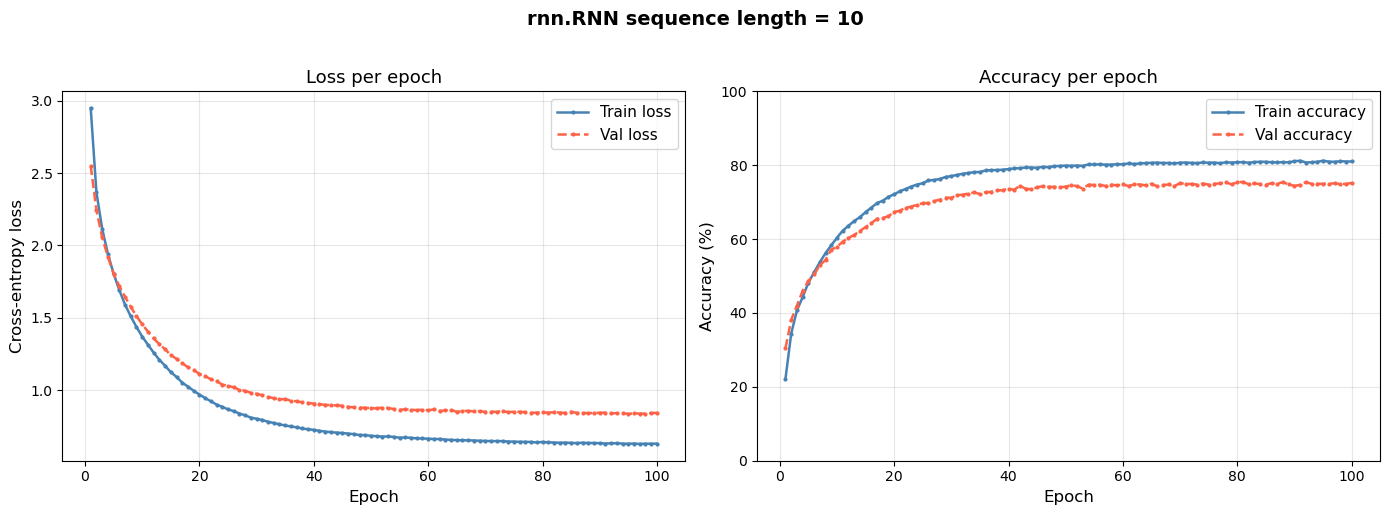

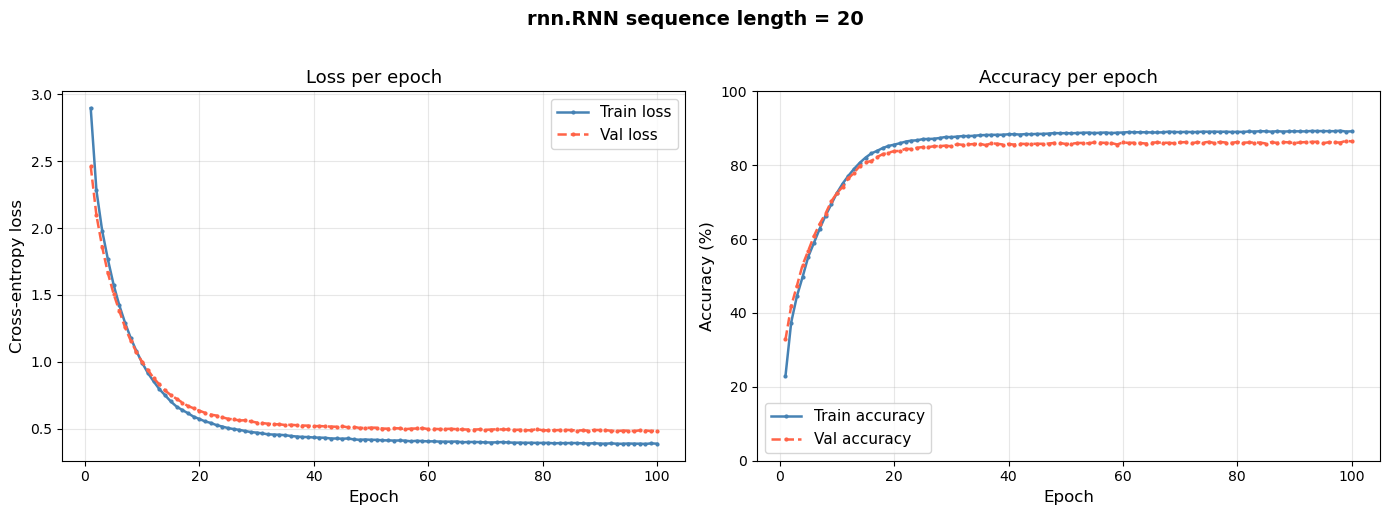

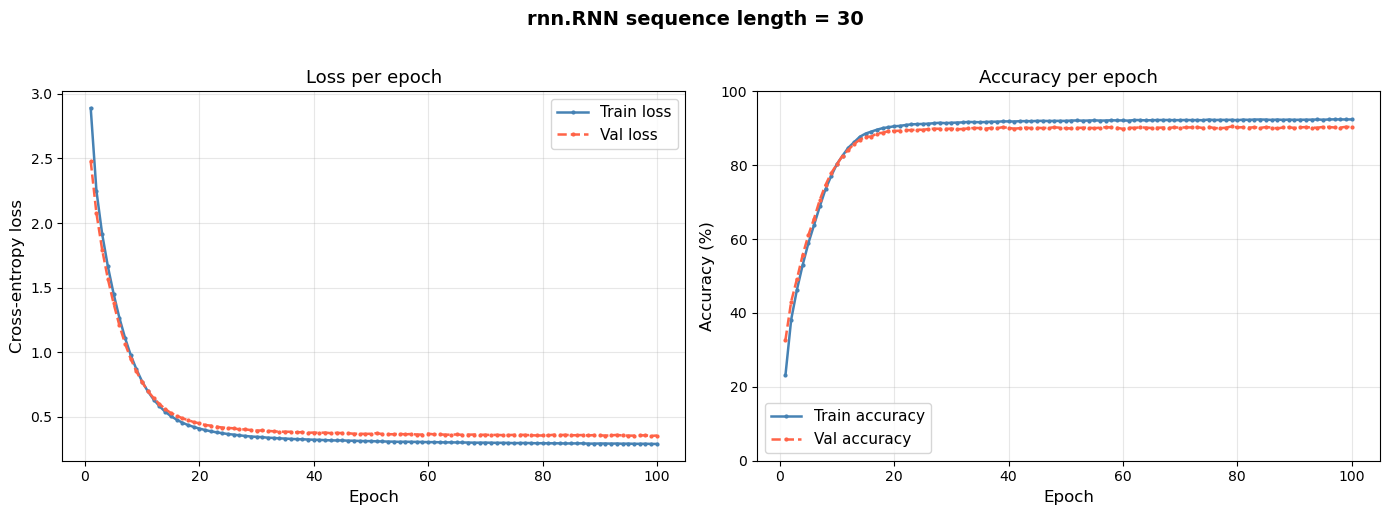

In [70]:
plot_curves(rnn_model, title='rnn.RNN sequence length = 10')
plot_curves(rnn_model20, title='rnn.RNN sequence length = 20')
plot_curves(rnn_model30, title='rnn.RNN sequence length = 30')